<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Logo-gustave-roussy.jpg/1200px-Logo-gustave-roussy.jpg" alt="Logo 1" width="250"/>
  <img src="https://upload.wikimedia.org/wikipedia/en/thumb/3/3f/Qube_Research_%26_Technologies_Logo.svg/1200px-Qube_Research_%26_Technologies_Logo.svg.png" alt="Logo 2" width="200" style="margin-left: 20px;"/>
</p>

# Data Challenge : Leukemia Risk Prediction


In [ ]:
import numpy as np
import pandas as pd
!pip install scikit-survival
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

In [ ]:
# 1. Enhanced cytogenetic feature extraction
def extract_advanced_cytogenetic_features(df):
    # Original cytogenetic features
    cyto_features = pd.DataFrame(index=df.index)

    # Basic karyotype classification
    cyto_features['normal_karyotype'] = df['CYTOGENETICS'].str.contains(r'^46,X[XY]$', regex=True).fillna(False).astype(int)

    # High-risk abnormalities
    cyto_features['complex_karyotype'] = df['CYTOGENETICS'].str.count(',') >= 3
    cyto_features['monosomy_7'] = df['CYTOGENETICS'].str.contains(r'-7|\(7;|\b7q-', regex=True).fillna(False).astype(int)
    cyto_features['del_5q'] = df['CYTOGENETICS'].str.contains(r'del\(5q\)|\b5q-', regex=True).fillna(False).astype(int)
    cyto_features['inv_3'] = df['CYTOGENETICS'].str.contains(r'inv\(3\)|t\(3;3\)', regex=True).fillna(False).astype(int)
    cyto_features['abn_17p'] = df['CYTOGENETICS'].str.contains(r'del\(17p\)|17p-', regex=True).fillna(False).astype(int)

    # Intermediate-risk abnormalities
    cyto_features['trisomy_8'] = df['CYTOGENETICS'].str.contains(r'\+8', regex=True).fillna(False).astype(int)
    cyto_features['t_9_11'] = df['CYTOGENETICS'].str.contains(r't\(9;11\)', regex=True).fillna(False).astype(int)

    # Favorable abnormalities
    cyto_features['inv_16'] = df['CYTOGENETICS'].str.contains(r'inv\(16\)|t\(16;16\)', regex=True).fillna(False).astype(int)
    cyto_features['t_8_21'] = df['CYTOGENETICS'].str.contains(r't\(8;21\)', regex=True).fillna(False).astype(int)

    # Additional important abnormalities
    cyto_features['t_6_9'] = df['CYTOGENETICS'].str.contains(r't\(6;9\)', regex=True).fillna(False).astype(int)
    cyto_features['t_11q23'] = df['CYTOGENETICS'].str.contains(r't\(11;|11q23', regex=True).fillna(False).astype(int)
    cyto_features['monosomy_5'] = df['CYTOGENETICS'].str.contains(r'-5', regex=True).fillna(False).astype(int)
    cyto_features['del_7q'] = df['CYTOGENETICS'].str.contains(r'del\(7q\)|\b7q-', regex=True).fillna(False).astype(int)
    cyto_features['abn_3q'] = df['CYTOGENETICS'].str.contains(r'3q', regex=True).fillna(False).astype(int)

    # Count number of abnormalities
    cyto_features['num_abnormalities'] = df['CYTOGENETICS'].str.count(',')
    cyto_features['num_abnormalities'].fillna(0, inplace=True)

    # Create cytogenetic risk score based on ELN 2017 classification
    # Favorable: t(8;21), inv(16), t(16;16)
    # Adverse: -5, -7, 5q-, 7q-, 3q, complex, t(6;9), 17p, etc.
    # Intermediate: normal karyotype, +8, etc.

    cyto_features['cyto_risk_score'] = 1  # Default: intermediate

    # Favorable
    favorable_mask = (cyto_features['t_8_21'] == 1) | (cyto_features['inv_16'] == 1)
    cyto_features.loc[favorable_mask, 'cyto_risk_score'] = 0

    # Adverse
    adverse_mask = ((cyto_features['complex_karyotype'] == 1) |
                    (cyto_features['monosomy_7'] == 1) |
                    (cyto_features['monosomy_5'] == 1) |
                    (cyto_features['del_5q'] == 1) |
                    (cyto_features['del_7q'] == 1) |
                    (cyto_features['inv_3'] == 1) |
                    (cyto_features['abn_17p'] == 1) |
                    (cyto_features['abn_3q'] == 1) |
                    (cyto_features['t_6_9'] == 1))
    cyto_features.loc[adverse_mask, 'cyto_risk_score'] = 2

    # Convert boolean to int
    for col in cyto_features.columns:
        if cyto_features[col].dtype == bool:
            cyto_features[col] = cyto_features[col].astype(int)

    return cyto_features

# 2. Enhanced molecular feature engineering
def create_advanced_molecular_features(df, maf_df, important_genes):
    # Create a DataFrame to store gene mutation features
    gene_features = pd.DataFrame(index=df['ID'].unique())

    # Basic mutation presence features
    for gene in important_genes:
        mutated_patients = maf_df[maf_df['GENE'] == gene]['ID'].unique()
        gene_features[f'has_{gene}_mutation'] = gene_features.index.isin(mutated_patients).astype(int)

    # Functional effect of mutations
    effect_types = ['missense', 'nonsense', 'frameshift', 'splice_site']

    for gene in important_genes:
        for effect in effect_types:
            # Find patients with this gene and this effect type
            patients = maf_df[(maf_df['GENE'] == gene) &
                             (maf_df['EFFECT'].str.contains(effect, case=False, na=False))]['ID'].unique()
            gene_features[f'{gene}_{effect}'] = gene_features.index.isin(patients).astype(int)

    # VAF-weighted features
    for gene in important_genes:
        # Get max VAF for this gene for each patient
        gene_vaf = maf_df[maf_df['GENE'] == gene].groupby('ID')['VAF'].max().reset_index()

        # Merge with gene features
        gene_vaf_dict = dict(zip(gene_vaf['ID'], gene_vaf['VAF']))
        gene_features[f'{gene}_vaf'] = gene_features.index.map(gene_vaf_dict).fillna(0)

        # Create impact score (presence * VAF)
        gene_features[f'{gene}_impact'] = gene_features[f'has_{gene}_mutation'] * gene_features[f'{gene}_vaf']

    # Clinically significant co-mutations
    # FLT3-NPM1 co-mutation is prognostically significant
    gene_features['FLT3_NPM1_comut'] = (gene_features['has_FLT3_mutation'] &
                                        gene_features['has_NPM1_mutation']).astype(int)

    # DNMT3A-NPM1 co-mutation
    gene_features['DNMT3A_NPM1_comut'] = (gene_features['has_DNMT3A_mutation'] &
                                         gene_features['has_NPM1_mutation']).astype(int)

    # TP53 pathway disruption (mutations in TP53 or related genes)
    gene_features['TP53_pathway_disruption'] = gene_features['has_TP53_mutation']

    # DNA methylation pathway disruption (DNMT3A, TET2, IDH1/2)
    gene_features['methylation_pathway_disruption'] = ((gene_features['has_DNMT3A_mutation'] |
                                                      gene_features['has_TET2_mutation'] |
                                                      gene_features['has_IDH1_mutation'] |
                                                      gene_features['has_IDH2_mutation']
                                                     )).astype(int)

    # Splicing pathway disruption (SRSF2, SF3B1)
    gene_features['splicing_pathway_disruption'] = ((gene_features['has_SRSF2_mutation'] |
                                                  gene_features['has_SF3B1_mutation']
                                                 )).astype(int)

    # Create molecular risk score based on known prognostic mutations
    gene_features['molecular_risk_score'] = 0

    # Favorable: NPM1 mutation without FLT3-ITD, CEBPA double mutation
    favorable_mask = (gene_features['has_NPM1_mutation'] == 1) & (gene_features['has_FLT3_mutation'] == 0)
    gene_features.loc[favorable_mask, 'molecular_risk_score'] = -1

    # Adverse: TP53, ASXL1, RUNX1
    adverse_mask = ((gene_features['has_TP53_mutation'] == 1) |
                   (gene_features['has_ASXL1_mutation'] == 1) |
                   (gene_features['has_RUNX1_mutation'] == 1))
    gene_features.loc[adverse_mask, 'molecular_risk_score'] = 1

    return gene_features.reset_index().rename(columns={'index': 'ID'})

# 3. Create advanced clinical features
def create_advanced_clinical_features(df):
    # Create a copy to avoid modifying original
    df_clinical = df.copy()

    # Basic ratio features
    df_clinical['ANC_to_WBC_ratio'] = df_clinical['ANC'] / df_clinical['WBC']
    df_clinical['MONO_to_WBC_ratio'] = df_clinical['MONOCYTES'] / df_clinical['WBC']
    df_clinical['MONO_to_LYM_ratio'] = df_clinical['MONOCYTES'] / (df_clinical['WBC'] - df_clinical['ANC'] - df_clinical['MONOCYTES'])
    df_clinical['PLT_to_WBC_ratio'] = df_clinical['PLT'] / df_clinical['WBC']

    # Replace infinities and NaNs
    df_clinical.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clinical.fillna(0, inplace=True)

    # Log transformations for skewed distributions
    for col in ['WBC', 'PLT', 'BM_BLAST']:
        df_clinical[f'log_{col}'] = np.log1p(df_clinical[col])

    # Categorical features based on clinical thresholds
    df_clinical['severe_anemia'] = (df_clinical['HB'] < 8).astype(int)
    df_clinical['moderate_anemia'] = ((df_clinical['HB'] >= 8) & (df_clinical['HB'] < 10)).astype(int)
    df_clinical['thrombocytopenia'] = (df_clinical['PLT'] < 100).astype(int)
    df_clinical['severe_thrombocytopenia'] = (df_clinical['PLT'] < 50).astype(int)
    df_clinical['leukocytosis'] = (df_clinical['WBC'] > 25).astype(int)
    df_clinical['high_blast'] = (df_clinical['BM_BLAST'] > 20).astype(int)

    # Composite clinical scores
    # Cytopenia score
    df_clinical['cytopenia_score'] = 0
    df_clinical.loc[df_clinical['HB'] < 10, 'cytopenia_score'] += 1
    df_clinical.loc[df_clinical['PLT'] < 100, 'cytopenia_score'] += 1
    df_clinical.loc[df_clinical['ANC'] < 1.8, 'cytopenia_score'] += 1

    # Proliferation index
    df_clinical['proliferation_index'] = 0
    df_clinical.loc[df_clinical['BM_BLAST'] > 10, 'proliferation_index'] += 1
    df_clinical.loc[df_clinical['WBC'] > 25, 'proliferation_index'] += 1

    # Interaction terms between key variables
    df_clinical['blast_wbc_interaction'] = df_clinical['BM_BLAST'] * df_clinical['WBC'] / 100
    df_clinical['hb_plt_interaction'] = df_clinical['HB'] * df_clinical['PLT'] / 100

    # Create simplified IPSS-like risk score for MDS/AML
    df_clinical['clinical_risk_score'] = 0

    # Add points for cytopenias
    df_clinical['clinical_risk_score'] += df_clinical['cytopenia_score']

    # Add points for blast percentage
    df_clinical.loc[df_clinical['BM_BLAST'] > 5, 'clinical_risk_score'] += 1
    df_clinical.loc[df_clinical['BM_BLAST'] > 10, 'clinical_risk_score'] += 1
    df_clinical.loc[df_clinical['BM_BLAST'] > 20, 'clinical_risk_score'] += 2

    return df_clinical

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*GOAL OF THE CHALLENGE and WHY IT IS IMPORTANT:*

The goal of the challenge is to **predict disease risk for patients with blood cancer**, in the context of specific subtypes of adult myeloid leukemias.

The risk is measured through the **overall survival** of patients, i.e. the duration of survival from the diagnosis of the blood cancer to the time of death or last follow-up.

Estimating the prognosis of patients is critical for an optimal clinical management.
For exemple, patients with low risk-disease will be offered supportive care to improve blood counts and quality of life, while patients with high-risk disease will be considered for hematopoietic stem cell transplantion.

The performance metric used in the challenge is the **IPCW-C-Index**.

*THE DATASETS*

The **training set is made of 3,323 patients**.

The **test set is made of 1,193 patients**.

For each patient, you have acces to CLINICAL data and MOLECULAR data.

The details of the data are as follows:

- OUTCOME:
  * OS_YEARS = Overall survival time in years
  * OS_STATUS = 1 (death) , 0 (alive at the last follow-up)

- CLINICAL DATA, with one line per patient:
  
  * ID = unique identifier per patient
  * CENTER = clinical center
  * BM_BLAST = Bone marrow blasts in % (blasts are abnormal blood cells)
  * WBC = White Blood Cell count in Giga/L
  * ANC = Absolute Neutrophil count in Giga/L
  * MONOCYTES = Monocyte count in Giga/L
  * HB = Hemoglobin in g/dL
  * PLT = Platelets coutn in Giga/L
  * CYTOGENETICS = A description of the karyotype observed in the blood cells of the patients, measured by a cytogeneticist. Cytogenetics is the science of chromosomes. A karyotype is performed from the blood tumoral cells. The convention for notation is ISCN (https://en.wikipedia.org/wiki/International_System_for_Human_Cytogenomic_Nomenclature). Cytogenetic notation are: https://en.wikipedia.org/wiki/Cytogenetic_notation. Note that a karyotype can be normal or abnornal. The notation 46,XX denotes a normal karyotype in females (23 pairs of chromosomes including 2 chromosomes X) and 46,XY in males (23 pairs of chromosomes inclusing 1 chromosme X and 1 chromsome Y). A common abnormality in the blood cancerous cells might be for exemple a loss of chromosome 7 (monosomy 7, or -7), which is typically asssociated with higher risk disease

- GENE MOLECULAR DATA, with one line per patient per somatic mutation. Mutations are detected from the sequencing of the blood tumoral cells.
We call somatic (= acquired) mutations the mutations that are found in the tumoral cells but not in other cells of the body.

  * ID = unique identifier per patient
  * CHR START END = position of the mutation on the human genome
  * REF ALT = reference and alternate (=mutant) nucleotide
  * GENE = the affected gene
  * PROTEIN_CHANGE = the consequence of the mutation on the protei that is expressed by a given gene
  * EFFECT = a broad categorization of the mutation consequences on a given gene.
  * VAF = Variant Allele Fraction = it represents the **proportion** of cells with the deleterious mutations.

In [ ]:


# Clinical Data
df = pd.read_csv("/content/drive/MyDrive/challenge_data/X_train/clinical_train.csv")
df_eval = pd.read_csv("/content/drive/MyDrive/challenge_data/X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("/content/drive/MyDrive/challenge_data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("/content/drive/MyDrive/challenge_data/X_test/molecular_test.csv")

target_df = pd.read_csv("/content/drive/MyDrive/challenge_data/target_train.csv")
#target_df_test = pd.read_csv("/content/drive/MyDrive/challenge_data/target_test.csv")

# Preview the data
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [ ]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

# Select features
features = ['BM_BLAST', 'HB', 'PLT']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df.loc[df['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


In [ ]:
# 1. Création de features basées sur les gènes - présence/absence de mutations dans les gènes importants
important_genes = ['TP53', 'ASXL1', 'RUNX1', 'FLT3', 'NPM1', 'IDH1', 'IDH2', 'DNMT3A', 'TET2', 'CEBPA', 'SRSF2', 'SF3B1']
gene_features = pd.DataFrame(index=df['ID'].unique())

# Pour chaque gène important, créer une feature binaire indiquant s'il est muté
for gene in important_genes:
    # Patients ayant une mutation dans ce gène
    mutated_patients = maf_df[maf_df['GENE'] == gene]['ID'].unique()
    # Créer une colonne binaire (1 si muté, 0 sinon)
    gene_features[f'has_{gene}_mutation'] = gene_features.index.isin(mutated_patients).astype(int)

"""# Créer des features de co-mutations
for gene1 in important_genes:
    for gene2 in important_genes:
        if gene1 < gene2:  # Pour éviter les doublons
            # Patients ayant les deux mutations
            gene1_patients = set(maf_df[maf_df['GENE'] == gene1]['ID'].unique())
            gene2_patients = set(maf_df[maf_df['GENE'] == gene2]['ID'].unique())
            comut_patients = gene1_patients.intersection(gene2_patients)

            # Créer la feature binaire
            col_name = f'comut_{gene1}_{gene2}'
            gene_features[col_name] = gene_features.index.isin(comut_patients).astype(int)"""

# 2. Statistiques sur les mutations par patient
mutation_counts = maf_df.groupby("ID").size().reset_index(name="Nmut")

# 3. Statistiques sur le VAF par patient
vaf_stats = maf_df.groupby("ID")["VAF"].agg(["mean", "max", "min", "std"]).reset_index()
vaf_stats.rename(columns={"mean": "vaf_mean", "max": "vaf_max", "min": "vaf_min", "std": "vaf_std"}, inplace=True)

# 4. Statistiques sur les types d'effets des mutations
effect_counts = pd.crosstab(maf_df['ID'], maf_df['EFFECT'])
effect_counts = effect_counts.reset_index()

# 5. Fusionner toutes les features moléculaires
mol_features = gene_features.reset_index().rename(columns={'index': 'ID'})
mol_features = pd.merge(mol_features, mutation_counts, on="ID", how="outer")
mol_features = pd.merge(mol_features, vaf_stats, on="ID", how="outer")
mol_features = pd.merge(mol_features, effect_counts, on="ID", how="outer")

# 6. Fusionner avec les données cliniques
df_enriched = df.merge(mol_features, on='ID', how='left')



####
# Extraire et ajouter les features cytogénétiques pour l'ensemble d'entraînement
cyto_features = extract_advanced_cytogenetic_features(df)
df_enriched = pd.concat([df_enriched, cyto_features], axis=1)




# Ajouter des ratios et scores cliniques pertinents
df_enriched['MONO_to_LYM_ratio'] = df_enriched['MONOCYTES'] / (df_enriched['WBC'] - df_enriched['ANC'] - df_enriched['MONOCYTES'])

# Remplacer les valeurs infinies ou NaN
df_enriched['MONO_to_LYM_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_enriched['MONO_to_LYM_ratio'].fillna(0, inplace=True)

# Score composite basé sur l'anémie, les plaquettes basses et les blastes élevés
# Ces facteurs sont connus pour être associés à un pronostic défavorable
df_enriched['cytopenia_score'] = 0
df_enriched.loc[df_enriched['HB'] < 10, 'cytopenia_score'] += 1  # Anémie
df_enriched.loc[df_enriched['PLT'] < 100, 'cytopenia_score'] += 1  # Thrombocytopénie
df_enriched.loc[df_enriched['BM_BLAST'] > 5, 'cytopenia_score'] += 1  # Blastes élevés

# Indicateur de pancytopénie (problème sur toutes les lignées)
df_enriched['pancytopenia'] = ((df_enriched['HB'] < 10) &
                              (df_enriched['PLT'] < 100) &
                              (df_enriched['ANC'] < 1.8)).astype(int)

# Indice de prolifération (combinaison de blastes élevés et globules blancs élevés)
df_enriched['proliferation_index'] = 0
df_enriched.loc[df_enriched['BM_BLAST'] > 10, 'proliferation_index'] += 1
df_enriched.loc[df_enriched['WBC'] > 25, 'proliferation_index'] += 1

# Rapport PLT/WBC (peut être indicatif de certains types de leucémie)
df_enriched['PLT_to_WBC_ratio'] = df_enriched['PLT'] / df_enriched['WBC']
df_enriched['PLT_to_WBC_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_enriched['PLT_to_WBC_ratio'].fillna(0, inplace=True)

# Score d'hypoplasie médullaire (indicateur de réserve médullaire réduite)
df_enriched['marrow_hypoplasia_score'] = 0
df_enriched.loc[df_enriched['HB'] < 8, 'marrow_hypoplasia_score'] += 1  # Anémie sévère
df_enriched.loc[df_enriched['PLT'] < 50, 'marrow_hypoplasia_score'] += 1  # Thrombocytopénie sévère
df_enriched.loc[df_enriched['ANC'] < 0.5, 'marrow_hypoplasia_score'] += 1  # Neutropénie sévère





# Ajouter des ratios qui pourraient être informatifs
df_enriched['ANC_to_WBC_ratio'] = df_enriched['ANC'] / df_enriched['WBC']
df_enriched['MONO_to_WBC_ratio'] = df_enriched['MONOCYTES'] / df_enriched['WBC']
df_enriched.replace([np.inf, -np.inf], np.nan, inplace=True)
df_enriched.fillna(0, inplace=True)

# Encoder le centre médical comme feature catégorielle
center_dummies = pd.get_dummies(df_enriched['CENTER'], prefix='center')
df_enriched = pd.concat([df_enriched, center_dummies], axis=1)
####

"""# Exemple pour créer des features de co-mutation
for gene1 in important_genes:
    for gene2 in important_genes:
        if gene1 < gene2:  # Pour éviter les doublons
            col_name = f'comut_{gene1}_{gene2}'
            df_enriched[col_name] = df_enriched[f'has_{gene1}_mutation'] & df_enriched[f'has_{gene2}_mutation']"""

# 7. Remplacer les valeurs manquantes par 0 (pour les patients sans données moléculaires)
# Cela signifie qu'ils n'ont pas de mutations détectées dans nos gènes d'intérêt
for col in df_enriched.columns:
    if col not in ['ID', 'CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'CYTOGENETICS']:
        df_enriched[col] = df_enriched[col].fillna(0)

# Pour les données cliniques, utiliser l'imputation
clinical_cols = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
imputer_clinical = SimpleImputer(strategy="median")
df_enriched[clinical_cols] = imputer_clinical.fit_transform(df_enriched[clinical_cols])
# Extraction d'informations à partir des données cytogénétiques


# 8. Sélectionner les features pour le modèle

########

clinical_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
gene_mut_features = [f'has_{gene}_mutation' for gene in important_genes]
stat_features = ['Nmut', 'vaf_mean', 'vaf_max', 'vaf_std']
effect_features = [col for col in effect_counts.columns if col != 'ID']
cyto_feature_list = ['normal_karyotype', 'complex_karyotype', 'monosomy_7', 'del_5q',
                     'inv_3', 'abn_17p', 'trisomy_8', 't_9_11', 'inv_16', 't_8_21']
ratio_features = ['ANC_to_WBC_ratio', 'MONO_to_WBC_ratio']
center_features = list(center_dummies.columns)
# Définir les nouvelles features cliniques composites
clinical_score_features = ['MONO_to_LYM_ratio', 'cytopenia_score', 'pancytopenia'] # 'proliferation_index', 'PLT_to_WBC_ratio', 'marrow_hypoplasia_score']

# Ajouter à la liste complète des features
features = (clinical_features + gene_mut_features + stat_features + effect_features + cyto_feature_list + ratio_features + clinical_score_features + center_features)

"""comut_features = [col for col in gene_features.columns if col.startswith('comut_')]"""


#####

# Créer les données pour l'entraînement
X = df_enriched.loc[df_enriched['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

# Split les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vérifier s'il y a des valeurs manquantes et les gérer
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

# Initialiser et entraîner le modèle Cox
cox = CoxPHSurvivalAnalysis(alpha=1)
cox.fit(X_train, y_train)

# Évaluer le modèle
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model with Advanced Molecular Features Concordance Index IPCW on train: {cox_cindex_train:.2f}")
print(f"Cox Proportional Hazard Model with Advanced Molecular Features Concordance Index IPCW on test: {cox_cindex_test:.2f}")


<ipython-input-16-066f981ada02>:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cyto_features['normal_karyotype'] = df['CYTOGENETICS'].str.contains(r'^46,X[XY]$', regex=True).fillna(False).astype(int)
<ipython-input-16-066f981ada02>:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cyto_features['monosomy_7'] = df['CYTOGENETICS'].str.contains(r'-7|\(7;|\b7q-', regex=True).fillna(False).astype(int)
<ipython-input-16-066f981ada02>:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versio

Cox Proportional Hazard Model with Advanced Molecular Features Concordance Index IPCW on train: 0.72
Cox Proportional Hazard Model with Advanced Molecular Features Concordance Index IPCW on test: 0.70
prout Index(['normal_karyotype', 'complex_karyotype', 'monosomy_7', 'del_5q',
       'inv_3', 'abn_17p', 'trisomy_8', 't_9_11', 'inv_16', 't_8_21', 't_6_9',
       't_11q23', 'monosomy_5', 'del_7q', 'abn_3q', 'num_abnormalities',
       'cyto_risk_score'],
      dtype='object')


In [ ]:
# 1. Créer les mêmes features moléculaires pour le jeu de test
gene_features_test = pd.DataFrame(index=df_eval['ID'].unique())

# Pour chaque gène important, créer une feature binaire
for gene in important_genes:
    # Patients ayant une mutation dans ce gène
    mutated_patients = maf_eval[maf_eval['GENE'] == gene]['ID'].unique()
    # Créer une colonne binaire (1 si muté, 0 sinon)
    gene_features_test[f'has_{gene}_mutation'] = gene_features_test.index.isin(mutated_patients).astype(int)

# Statistiques sur les mutations par patient
mutation_counts_test = maf_eval.groupby("ID").size().reset_index(name="Nmut")

# Statistiques sur le VAF par patient
vaf_stats_test = maf_eval.groupby("ID")["VAF"].agg(["mean", "max", "min", "std"]).reset_index()
vaf_stats_test.rename(columns={"mean": "vaf_mean", "max": "vaf_max", "min": "vaf_min", "std": "vaf_std"}, inplace=True)

# Statistiques sur les types d'effets des mutations
effect_counts_test = pd.crosstab(maf_eval['ID'], maf_eval['EFFECT'])
effect_counts_test = effect_counts_test.reset_index()

# Fusionner toutes les features moléculaires
mol_features_test = gene_features_test.reset_index().rename(columns={'index': 'ID'})
mol_features_test = pd.merge(mol_features_test, mutation_counts_test, on="ID", how="outer")
mol_features_test = pd.merge(mol_features_test, vaf_stats_test, on="ID", how="outer")
mol_features_test = pd.merge(mol_features_test, effect_counts_test, on="ID", how="outer")

# Fusionner avec les données cliniques
df_eval_enriched = df_eval.merge(mol_features_test, on='ID', how='left')


# Remplacer les valeurs manquantes
for col in df_eval_enriched.columns:
    if col not in ['ID', 'CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'CYTOGENETICS']:
        df_eval_enriched[col] = df_eval_enriched[col].fillna(0)

#####
# Pour les données cliniques, utiliser l'imputation
df_eval_enriched[clinical_cols] = imputer_clinical.transform(df_eval_enriched[clinical_cols])

# Extraire et ajouter les features cytogénétiques pour l'ensemble d'évaluation
cyto_features_test = extract_advanced_cytogenetic_features(df_eval)
df_eval_enriched = pd.concat([df_eval_enriched, cyto_features_test], axis=1)

# Ajouter les mêmes ratios que pour l'entraînement
df_eval_enriched['ANC_to_WBC_ratio'] = df_eval_enriched['ANC'] / df_eval_enriched['WBC']
df_eval_enriched['MONO_to_WBC_ratio'] = df_eval_enriched['MONOCYTES'] / df_eval_enriched['WBC']
df_eval_enriched.replace([np.inf, -np.inf], np.nan, inplace=True)
df_eval_enriched.fillna(0, inplace=True)



# Ratio Monocytes/Lymphocytes
df_eval_enriched['MONO_to_LYM_ratio'] = df_eval_enriched['MONOCYTES'] / (df_eval_enriched['WBC'] - df_eval_enriched['ANC'] - df_eval_enriched['MONOCYTES'])
df_eval_enriched['MONO_to_LYM_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_eval_enriched['MONO_to_LYM_ratio'].fillna(0, inplace=True)

# Score de cytopénie
df_eval_enriched['cytopenia_score'] = 0
df_eval_enriched.loc[df_eval_enriched['HB'] < 10, 'cytopenia_score'] += 1
df_eval_enriched.loc[df_eval_enriched['PLT'] < 100, 'cytopenia_score'] += 1
df_eval_enriched.loc[df_eval_enriched['BM_BLAST'] > 5, 'cytopenia_score'] += 1

# Indicateur de pancytopénie
df_eval_enriched['pancytopenia'] = ((df_eval_enriched['HB'] < 10) &
                                   (df_eval_enriched['PLT'] < 100) &
                                   (df_eval_enriched['ANC'] < 1.8)).astype(int)

# Indice de prolifération
df_eval_enriched['proliferation_index'] = 0
df_eval_enriched.loc[df_eval_enriched['BM_BLAST'] > 10, 'proliferation_index'] += 1
df_eval_enriched.loc[df_eval_enriched['WBC'] > 25, 'proliferation_index'] += 1

# Rapport PLT/WBC
df_eval_enriched['PLT_to_WBC_ratio'] = df_eval_enriched['PLT'] / df_eval_enriched['WBC']
df_eval_enriched['PLT_to_WBC_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_eval_enriched['PLT_to_WBC_ratio'].fillna(0, inplace=True)

# Score d'hypoplasie médullaire
df_eval_enriched['marrow_hypoplasia_score'] = 0
df_eval_enriched.loc[df_eval_enriched['HB'] < 8, 'marrow_hypoplasia_score'] += 1
df_eval_enriched.loc[df_eval_enriched['PLT'] < 50, 'marrow_hypoplasia_score'] += 1
df_eval_enriched.loc[df_eval_enriched['ANC'] < 0.5, 'marrow_hypoplasia_score'] += 1









# Encoder le centre médical
center_dummies_test = pd.get_dummies(df_eval_enriched['CENTER'], prefix='center')

# Assurer la cohérence des colonnes entre train et test
for col in center_dummies.columns:
    if col not in center_dummies_test.columns:
        center_dummies_test[col] = 0

df_eval_enriched = pd.concat([df_eval_enriched, center_dummies_test], axis=1)
"""
# Créer des features de co-mutations pour l'ensemble de test
for gene1 in important_genes:
    for gene2 in important_genes:
        if gene1 < gene2:
            # Patients ayant les deux mutations
            gene1_patients = set(maf_eval[maf_eval['GENE'] == gene1]['ID'].unique())
            gene2_patients = set(maf_eval[maf_eval['GENE'] == gene2]['ID'].unique())
            comut_patients = gene1_patients.intersection(gene2_patients)

            # Créer la feature binaire
            col_name = f'comut_{gene1}_{gene2}'
            gene_features_test[col_name] = gene_features_test.index.isin(comut_patients).astype(int)"""
# Vérifier que toutes les features d'entraînement sont présentes dans l'ensemble d'évaluation
for feature in features:
    if feature not in df_eval_enriched.columns:
        df_eval_enriched[feature] = 0  # Ajouter colonne manquante avec valeurs par défaut
  ########

# S'assurer que les features sont dans le même ordre
X_eval = df_eval_enriched.loc[:, features]

# Vérifier s'il y a des valeurs manquantes et les gérer
X_eval.fillna(0, inplace=True)

# Faire les prédictions
prediction_on_test_set = cox.predict(X_eval)
###
# Faire les prédictions en utilisant les mêmes features que pour l'entraînement
#prediction_on_test_set = cox.predict(df_eval_enriched.loc[:, features])

# Créer le fichier de soumission
submission_df = pd.DataFrame({'ID': df_eval_enriched['ID'], 'risk_score': prediction_on_test_set})
submission_df.to_csv('/content/drive/MyDrive/challenge_data/resultats/submission_advanced.csv', index=False)
print("Fichier de soumission créé avec succès!")

<ipython-input-16-066f981ada02>:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cyto_features['normal_karyotype'] = df['CYTOGENETICS'].str.contains(r'^46,X[XY]$', regex=True).fillna(False).astype(int)
<ipython-input-16-066f981ada02>:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cyto_features['monosomy_7'] = df['CYTOGENETICS'].str.contains(r'-7|\(7;|\b7q-', regex=True).fillna(False).astype(int)
<ipython-input-16-066f981ada02>:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versio

Fichier de soumission créé avec succès!


<ipython-input-20-4120a94f9a8e>:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_eval_enriched['PLT_to_WBC_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
<ipython-input-20-4120a94f9a8e>:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [ ]:
# Initialiser et entraîner le modèle RSF
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
rsf.fit(X_train, y_train)

# Évaluer le modèle
rsf_cindex_train = concordance_index_ipcw(y_train, y_train, rsf.predict(X_train), tau=7)[0]
rsf_cindex_test = concordance_index_ipcw(y_train, y_test, rsf.predict(X_test), tau=7)[0]
print(f"Random Survival Forest Concordance Index IPCW on train: {rsf_cindex_train:.5f}")
print(f"Random Survival Forest Concordance Index IPCW on test: {rsf_cindex_test:.5f}")

cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"cox Concordance Index IPCW on train: {cox_cindex_train:.5f}")
print(f"cox Concordance Index IPCW on test: {cox_cindex_test:.5f}")

# Si les performances sont meilleures, utilisez ce modèle pour les prédictions finales
if rsf_cindex_test > cox_cindex_test:
    print("Le Random Survival Forest est meilleur - utilisation pour les prédictions finales")
    prediction_on_test_set = rsf.predict(df_eval_enriched.loc[:, features])
    submission_df = pd.DataFrame({'ID': df_eval_enriched['ID'], 'risk_score': prediction_on_test_set})
    submission_df.to_csv('/content/drive/MyDrive/challenge_data/resultats/submission_rsf.csv', index=False)

Random Survival Forest Concordance Index IPCW on train: 0.73633
Random Survival Forest Concordance Index IPCW on test: 0.70928
cox Concordance Index IPCW on train: 0.72363
cox Concordance Index IPCW on test: 0.70345
Le Random Survival Forest est meilleur - utilisation pour les prédictions finales


In [ ]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# Initialiser et entraîner le modèle GradientBoostingSurvivalAnalysis
xgb_surv = GradientBoostingSurvivalAnalysis(random_state=42,
    n_estimators= 850,
    learning_rate=0.03160736770883459,
    max_depth= 3,
    subsample= 0.8118022194771892,
    min_samples_leaf=4,
    min_samples_split=4
)
xgb_surv.fit(X_train, y_train)

# Évaluer le modèle
xgb_cindex_train = concordance_index_ipcw(y_train, y_train, xgb_surv.predict(X_train), tau=7)[0]
xgb_cindex_test = concordance_index_ipcw(y_train, y_test, xgb_surv.predict(X_test), tau=7)[0]
print(f"XGBoost Survival (sksurv) Concordance Index IPCW on train: {xgb_cindex_train:.5f}")
print(f"XGBoost Survival (sksurv) Concordance Index IPCW on test: {xgb_cindex_test:.5f}")

# Prédictions sur l'ensemble de test final
prediction_xgb_test_set = xgb_surv.predict(df_eval_enriched.loc[:, features])

# Créer le fichier de soumission
submission_df = pd.DataFrame({'ID': df_eval_enriched['ID'], 'risk_score': prediction_xgb_test_set})
submission_df.to_csv('/content/drive/MyDrive/challenge_data/resultats/submission_xgboost_sksurv.csv', index=False)

XGBoost Survival (sksurv) Concordance Index IPCW on train: 0.79647
XGBoost Survival (sksurv) Concordance Index IPCW on test: 0.72020


In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.5 MB/s eta 0:00:00


In [ ]:
import optuna

# Defining the function, with the parameters space inside
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        #"colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        #"reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        #"reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 50.0, log=True)
    }

    # Training the Regressor
    model = GradientBoostingSurvivalAnalysis(random_state=42, **params)
    model.fit(
        X_train, y_train,
        #eval_set=[(X_test_B, y_test_B)],
        #verbose=False
    )
    # Évaluer le modèle
    xgb_cindex_train = concordance_index_ipcw(y_train, y_train, model.predict(X_train), tau=7)[0]
    xgb_cindex_test = concordance_index_ipcw(y_train, y_test, model.predict(X_test), tau=7)[0]
    print(f"XGBoost Survival (sksurv) Concordance Index IPCW on train: {xgb_cindex_train:.5f}")
    print(f"XGBoost Survival (sksurv) Concordance Index IPCW on test: {xgb_cindex_test:.5f}")
    return xgb_cindex_test

# Optimizing with Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Printing the best hyperparameters
print(f"Meilleurs hyperparamètres : {study.best_params}")

[I 2025-03-12 16:02:43,497] A new study created in memory with name: no-name-09e129dc-7260-4d6e-8700-7d1767df5bc7
[I 2025-03-12 16:03:46,090] Trial 0 finished with value: 0.6936437279259806 and parameters: {'n_estimators': 1000, 'learning_rate': 0.2591291958441133, 'max_depth': 5, 'subsample': 0.7681330967066047, 'min_samples_leaf': 7, 'min_samples_split': 15}. Best is trial 0 with value: 0.6936437279259806.


XGBoost Survival (sksurv) Concordance Index IPCW on train: 0.98745
XGBoost Survival (sksurv) Concordance Index IPCW on test: 0.69364


[I 2025-03-12 16:04:31,862] Trial 1 finished with value: 0.7056022363945252 and parameters: {'n_estimators': 850, 'learning_rate': 0.14193884797124334, 'max_depth': 5, 'subsample': 0.5292539094992235, 'min_samples_leaf': 7, 'min_samples_split': 11}. Best is trial 1 with value: 0.7056022363945252.


XGBoost Survival (sksurv) Concordance Index IPCW on train: 0.96318
XGBoost Survival (sksurv) Concordance Index IPCW on test: 0.70560


[I 2025-03-12 16:04:39,430] Trial 2 finished with value: 0.714170849310753 and parameters: {'n_estimators': 150, 'learning_rate': 0.1921415439622742, 'max_depth': 3, 'subsample': 0.5598970448046059, 'min_samples_leaf': 2, 'min_samples_split': 4}. Best is trial 2 with value: 0.714170849310753.


...

XGBoost Survival (sksurv) Concordance Index IPCW on train: 0.78058
XGBoost Survival (sksurv) Concordance Index IPCW on test: 0.71853


[I 2025-03-12 16:15:59,226] Trial 18 finished with value: 0.7009990491106479 and parameters: {'n_estimators': 400, 'learning_rate': 0.28896687645302027, 'max_depth': 6, 'subsample': 0.7181288240860588, 'min_samples_leaf': 4, 'min_samples_split': 4}. Best is trial 3 with value: 0.7202007732364873.


XGBoost Survival (sksurv) Concordance Index IPCW on train: 0.98512
XGBoost Survival (sksurv) Concordance Index IPCW on test: 0.70100


[I 2025-03-12 16:16:35,894] Trial 19 finished with value: 0.7061518348227115 and parameters: {'n_estimators': 700, 'learning_rate': 0.08931991455781949, 'max_depth': 4, 'subsample': 0.5046710301944093, 'min_samples_leaf': 2, 'min_samples_split': 11}. Best is trial 3 with value: 0.7202007732364873.


XGBoost Survival (sksurv) Concordance Index IPCW on train: 0.89335
XGBoost Survival (sksurv) Concordance Index IPCW on test: 0.70615
Meilleurs hyperparamètres : {'n_estimators': 850, 'learning_rate': 0.03160736770883459, 'max_depth': 3, 'subsample': 0.8118022194771892, 'min_samples_leaf': 4, 'min_samples_split': 4}


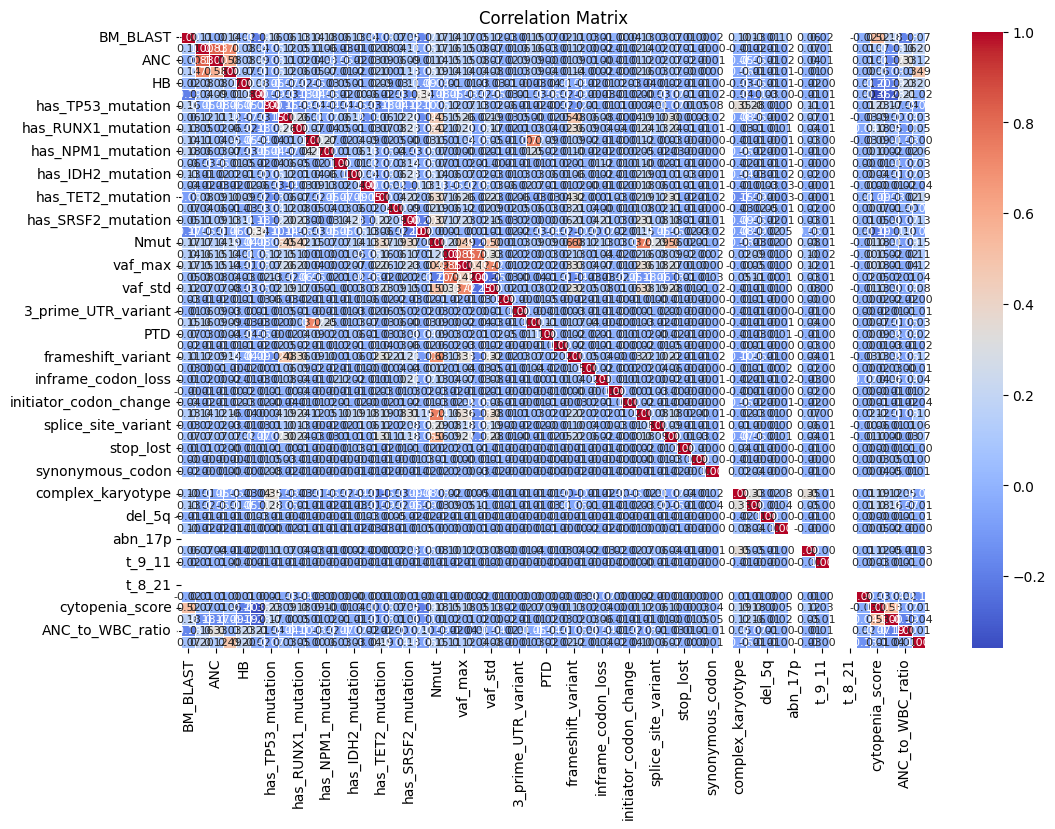

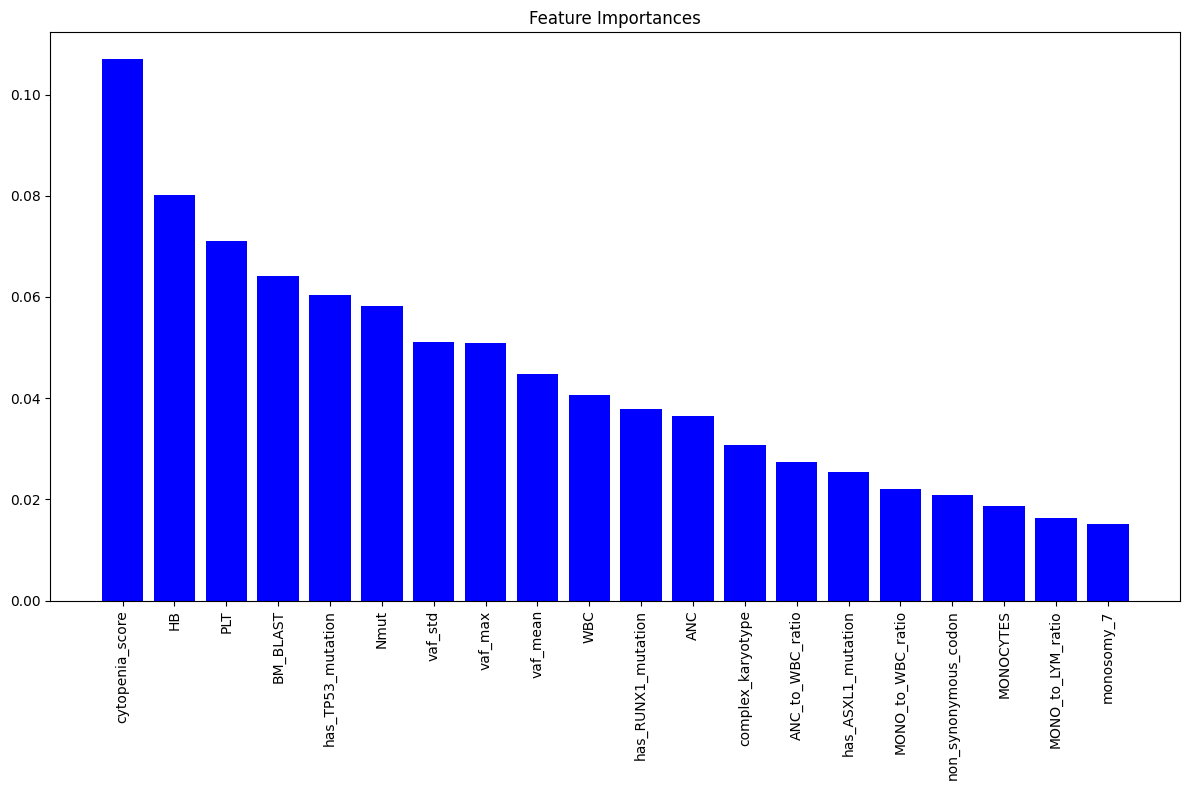

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fit

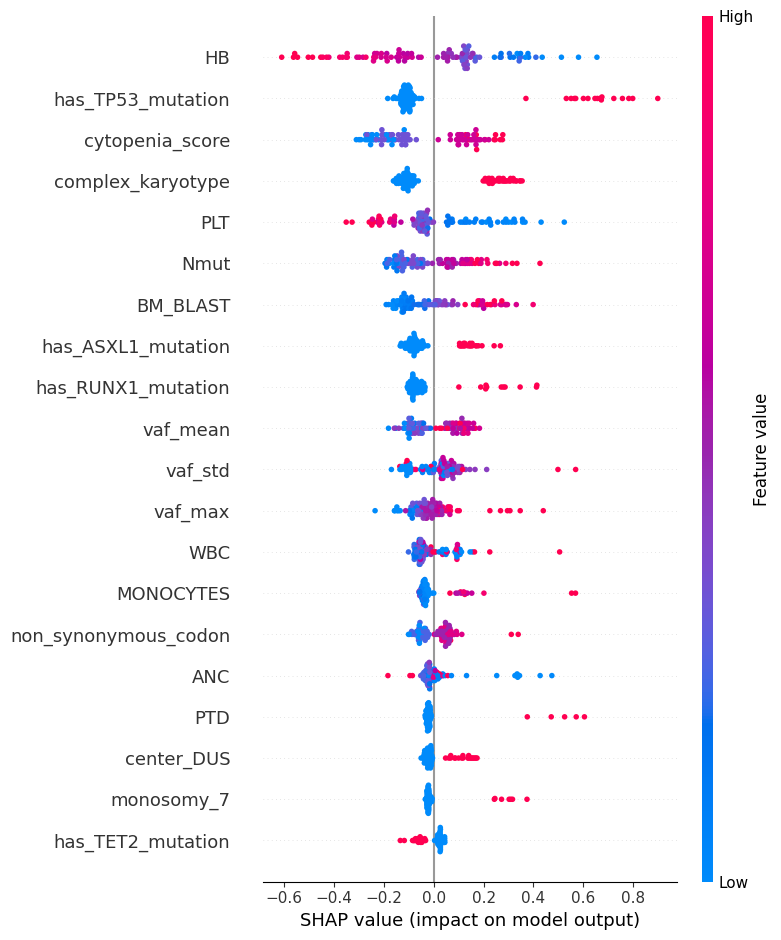

In [ ]:
# Install packages
!pip install seaborn
!pip install shap

# Import libraries
import shap
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Correlation matrix visualization
corr_matrix = df_enriched[df_enriched.select_dtypes(include=[np.number]).columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Matrix')
plt.show()

# Pour un modèle GradientBoostingSurvivalAnalysis
feature_importances = xgb_surv.feature_importances_
indices = np.argsort(feature_importances)[::-1]

# Récupérer les noms des features (à adapter selon votre dataframe)
feature_names = X_train.columns

plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(len(indices[:20])), feature_importances[indices[:20]], color='b', align='center')
plt.xticks(range(len(indices[:20])), [feature_names[i] for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()

# Créer un background dataset (un sous-ensemble des données d'entraînement)
background = X_train.sample(min(100, len(X_train)))  # Limiter à 100 échantillons pour la performance

# Définir une fonction de prédiction
def predict_fn(x):
    # Adapter cette fonction selon ce que vous voulez expliquer
    # Par exemple, pour prédire le risque/hazard ratio
    return xgb_surv.predict(x)

# Créer l'explainer et calculer les valeurs SHAP
explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(X_test.iloc[:100])  # Limiter pour la performance

# Visualiser
shap.summary_plot(shap_values, X_test.iloc[:100])